In [55]:
import torch
import yaml
import argparse
import os
import numpy as np
from tqdm import tqdm
from torch.optim import AdamW
from torch.utils.data import DataLoader
from DiT_v2 import DiT
from VAE import VAE
from DDPM import LinearNoiseScheduler
from img_dataloader import dataset_imgs

from torchvision.utils import make_grid
import torchvision

In [14]:
dataset = dataset_imgs("Temp Dataset")
dataloader = DataLoader(dataset, batch_size = 10, shuffle = True)

In [5]:
num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02

In [6]:
scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(ch = 128, latent_channels = 4).to(device)


dit = DiT(d_model        = 256,
          g_channels       = 4,
          grid_size      = 32,
          patch_size     = 4,
          timestep_emb_dim  = 128,
        #   num_freq       = 128,
          num_layers     = 8,
          num_heads      = 4)

vae.eval()
dit.train()

In [10]:
optimizer = AdamW(dit.parameters(), lr=1E-5, weight_decay=0)
loss_fn   = torch.nn.MSELoss()

In [11]:
for param in vae.parameters():
    param.requires_grad = False

In [16]:
losses = []
epochs = 10
for epoch in range(epochs):
    epoch_loss = 0.0
    for images, _x_t, _noise, _t, numbers in dataloader:
        images  = images.to(device)
        # numbers = numbers.float().to(device)

        with torch.no_grad():
            mu, logvar = vae.encode(images)
            z = vae.reparameterize(mu, logvar)

        # Sample random noise
        noise = torch.randn_like(z).to(device)

        # Sample timestep
        t = torch.randint(0, 1000,(z.shape[0],)).to(device)

        noisy_im = scheduler.add_noise(z, noise, t)

        pred = dit(noisy_im, t)
        loss = loss_fn(pred, noise)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
    avg = epoch_loss / len(dataloader)
    losses.append(avg)
    print(f"[DiT] Epoch {epoch+1}/{epochs}  loss={avg:.6f}")


[DiT] Epoch 1/10  loss=0.994229
[DiT] Epoch 2/10  loss=0.996852
[DiT] Epoch 3/10  loss=0.996022
[DiT] Epoch 4/10  loss=1.009875
[DiT] Epoch 5/10  loss=0.999664
[DiT] Epoch 6/10  loss=0.993667
[DiT] Epoch 7/10  loss=0.995237
[DiT] Epoch 8/10  loss=0.985679
[DiT] Epoch 9/10  loss=0.991042
[DiT] Epoch 10/10  loss=0.986792


In [ ]:
def sample_v2(latent_grid_size: int, grid_size: int):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, torch.as_tensor(i).unsqueeze(0).to(device))
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

        if i == 0:
            g = vae.to(device).decode(xt)
        else:
            g = xt
            g = xt[:, :-1, :, :]
        
        g = torch.clamp(g, -1., 1.).detach().cpu()
        g = (g + 1) / 2

        grid = make_grid(g, nrow = 2)
        img = torchvision.transforms.ToPILImage()(grid)
        return img

0it [00:00, ?it/s]

1000it [00:25, 39.96it/s]


In [54]:
grid.shape

torch.Size([3, 256, 256])

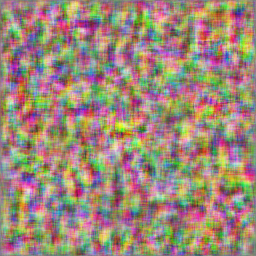

In [57]:
img

In [ ]:
def sample(model, scheduler, train_config, dit_model_config,
           autoencoder_model_config, diffusion_config, dataset_config, vae):

    im_size = dataset_config['im_size'] // 2 ** sum(autoencoder_model_config['down_sample'])
    xt = torch.randn((train_config['num_samples'],
                      autoencoder_model_config['z_channels'],
                      im_size,
                      im_size)).to(device)

    for i in tqdm(reversed(range(diffusion_config['num_timesteps']))):
        # Get prediction of noise
        noise_pred = model(xt, torch.as_tensor(i).unsqueeze(0).to(device))

        # Use scheduler to get x0 and xt-1
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

        # Save x0
        # ims = torch.clamp(xt, -1., 1.).detach().cpu()
        if i == 0:
            # Decode ONLY the final image to save time
            ims = vae.to(device).decode(xt)
        else:
            ims = xt
            ims = xt[:, :-1, :, :]

        ims = torch.clamp(ims, -1., 1.).detach().cpu()
        ims = (ims + 1) / 2

        grid = make_grid(ims, nrow = train_config['num_grid_rows'])
        img = torchvision.transforms.ToPILImage()(grid)

        if not os.path.exists(os.path.join(train_config['task_name'], 'samples')):
            os.mkdir(os.path.join(train_config['task_name'], 'samples'))
        img.save(os.path.join(train_config['task_name'], 'samples', 'x0_{}.png'.format(i)))
        img.close()